In [48]:
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import librosa
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization, Flatten, Dense
import numpy as np

data = "./features.csv"

df = pd.read_csv(data)

df["segment"] = None
for index, row in df.iterrows():
    start_sample = int(row["Start Sample"])
    end_sample = int(row["End Sample"])
    signal, fs= librosa.load(row["file"])
    segment = signal[start_sample:end_sample]
    df.at[index, "segment"] = segment  

# max_len = max(len(segment) for segment in df["segment"]) 
max_len = 100
def pad_segment(segment, max_len):
    if len(segment) > max_len:
        return segment[:max_len]           
    else:
        return np.pad(segment, (0, max_len - len(segment)))  

X = np.array([pad_segment(seg, max_len) for seg in df["segment"]])
X = X[..., np.newaxis]

y = df['Label'] 

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [49]:

LEARNING_RATE = 0.01

model = Sequential([
    Conv1D(
        128, 3, activation='relu', padding='same',
        input_shape=(max_len, 1)
    ),
    MaxPooling1D(2),
    Dropout(0.15),
    BatchNormalization(),
    Conv1D(
        256, 3, activation='relu', padding='same'
    ),
    MaxPooling1D(2),
    Dropout(0.15),
    BatchNormalization(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.15),
    BatchNormalization(),
    Dense(3, activation='softmax')
])


c:\Users\joaqu\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:

y_train.shape

(2807,)

In [51]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

monitor = EarlyStopping(monitor='val_acc',
                        mode='max',
                        restore_best_weights=True,
                        patience=5)


In [52]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    validation_split=0.1,
                    callbacks=[monitor],)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - acc: 0.4527 - loss: 1.3079 - val_acc: 0.4199 - val_loss: 1.0741
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.4810 - loss: 1.0509 - val_acc: 0.3452 - val_loss: 1.1055
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.5063 - loss: 0.9924 - val_acc: 0.3452 - val_loss: 1.1071
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.4903 - loss: 1.0347 - val_acc: 0.5196 - val_loss: 1.0311
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.5008 - loss: 1.0081 - val_acc: 0.5089 - val_loss: 0.9785
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.5053 - loss: 1.0216 - val_acc: 0.4342 - val_loss: 1.0057
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - acc: 0.5264 - loss: 0.9732 - val_acc: 0.5125 - val_loss: 0.9870
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.5094 - loss: 0.9701 - val_acc: 0.5125 - val_loss: 0.9905
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.5046


++++++++++++ Test data ++++++++++++
loss=1.0250 acc=0.5456


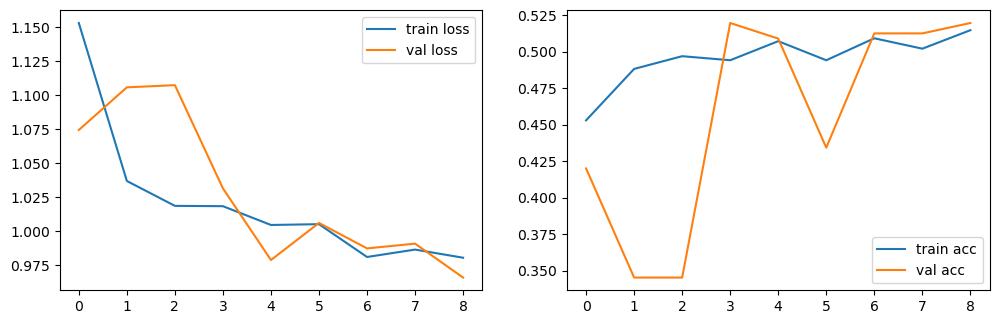

In [53]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['acc'], label='train acc')
plt.plot(history.history['val_acc'], label='val acc')
plt.legend()

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n++++++++++++ Test data ++++++++++++\nloss={loss:.4f} acc={acc:.4f}")